In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from category_encoders import TargetEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_curve

In [ ]:
test = pd.read_csv('/content/test.csv')
train = pd.read_csv('/content/train.csv')

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [ ]:
print(train.columns.tolist())

['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_paid_back']


In [ ]:
train.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


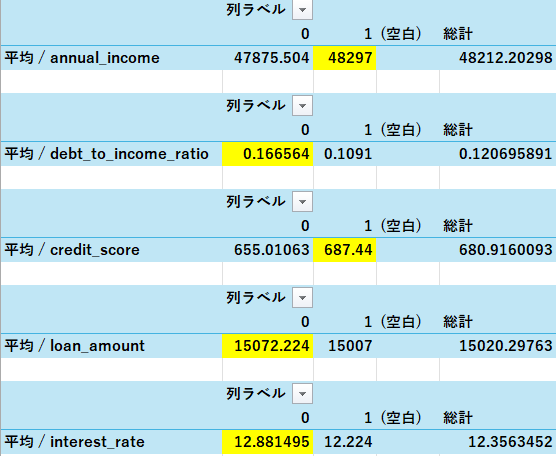

仮説：

- **年収-annual income**の高い方がローンを返済する

- **返済負担率-dept to income ratio**の低い方がローンを返済する

- **credit score**の高い方がローンを返済する

- **融資額-loan amount**の低い方がローンを返済する

- **金利-interest rate**の低い方がローンを返済する


**雇用状態-employment status**

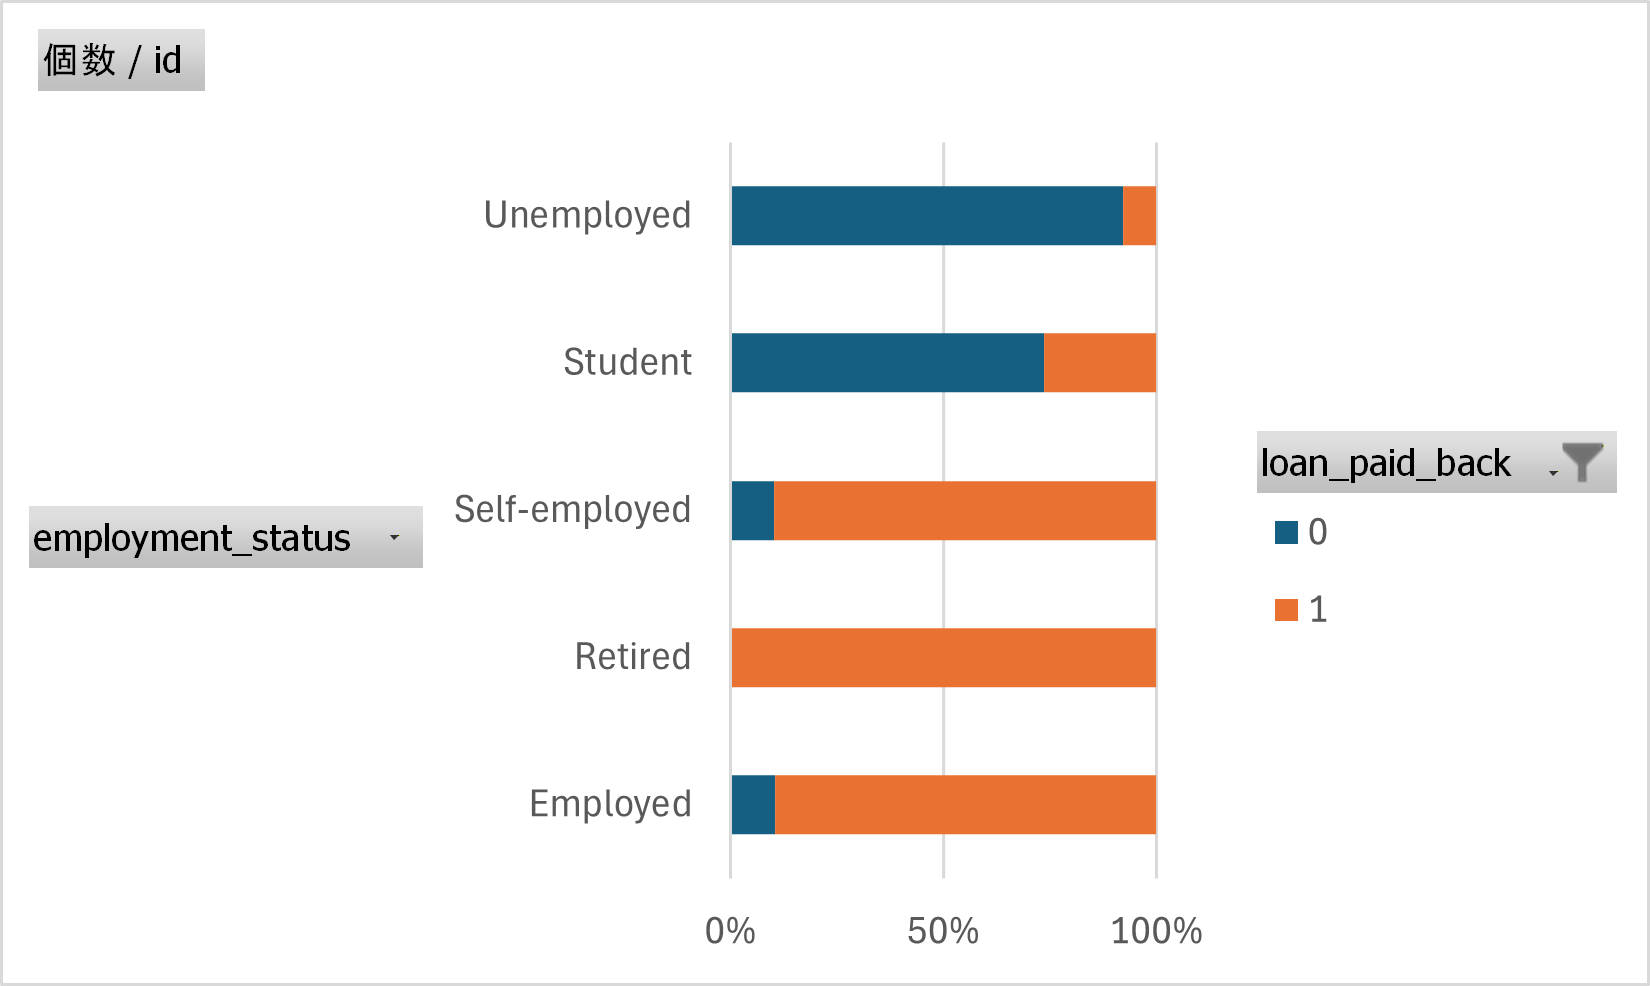

ローンを返済していない割合が高い：Unemployed, Student

ローンを返済する割合が高い：Self-employed, Retired, Employed

**等級-grade subgrade**

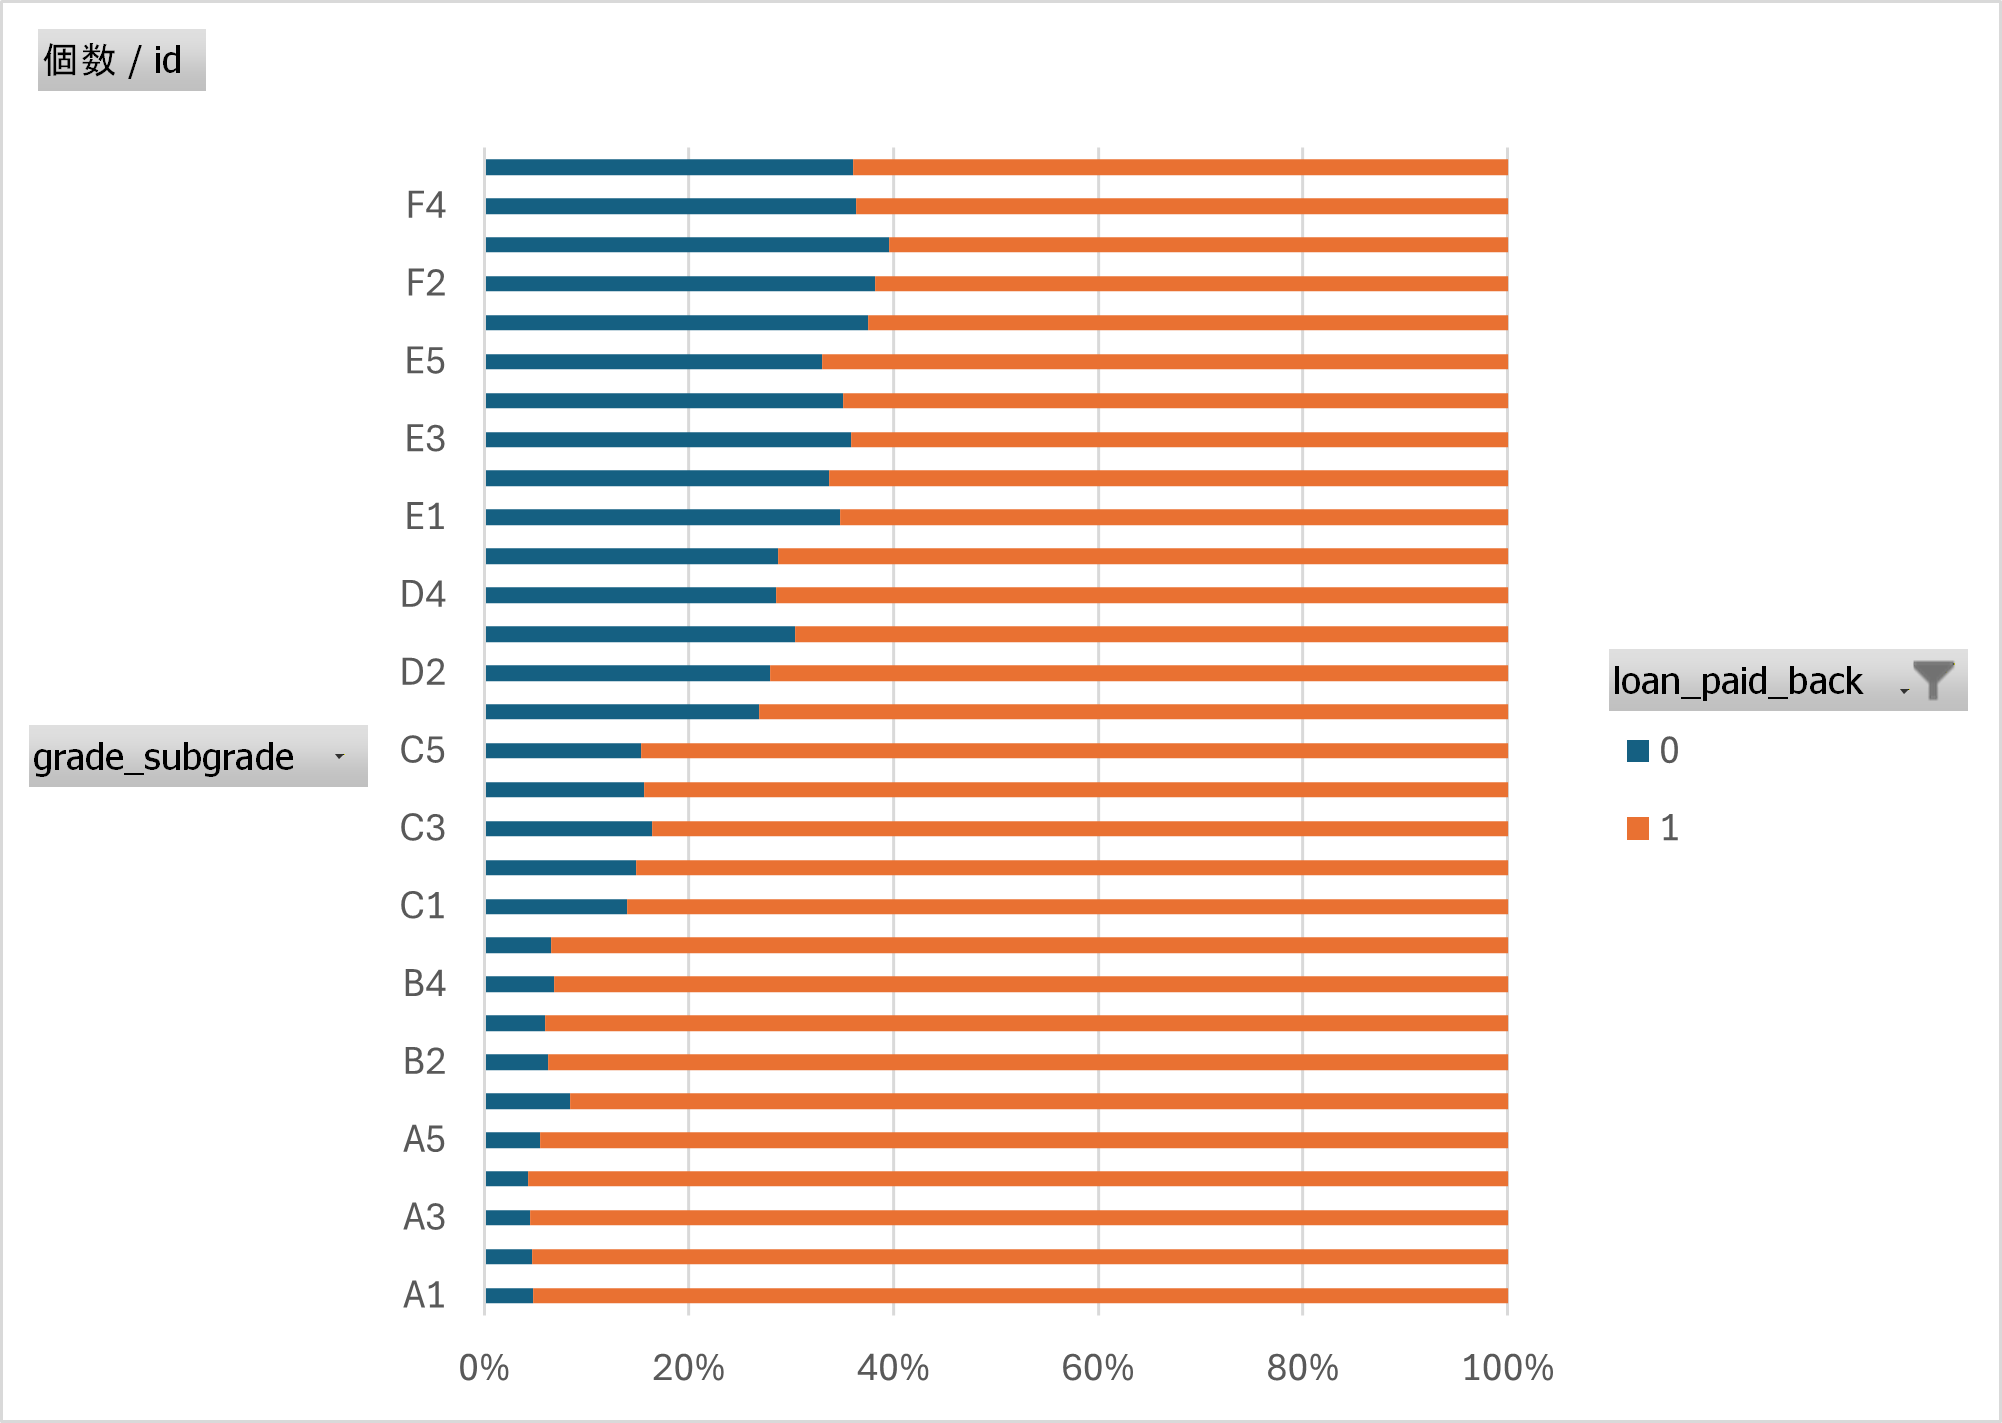

等級が高いほどローンを返済している割合が高い

**ローン目的-loan purpose**

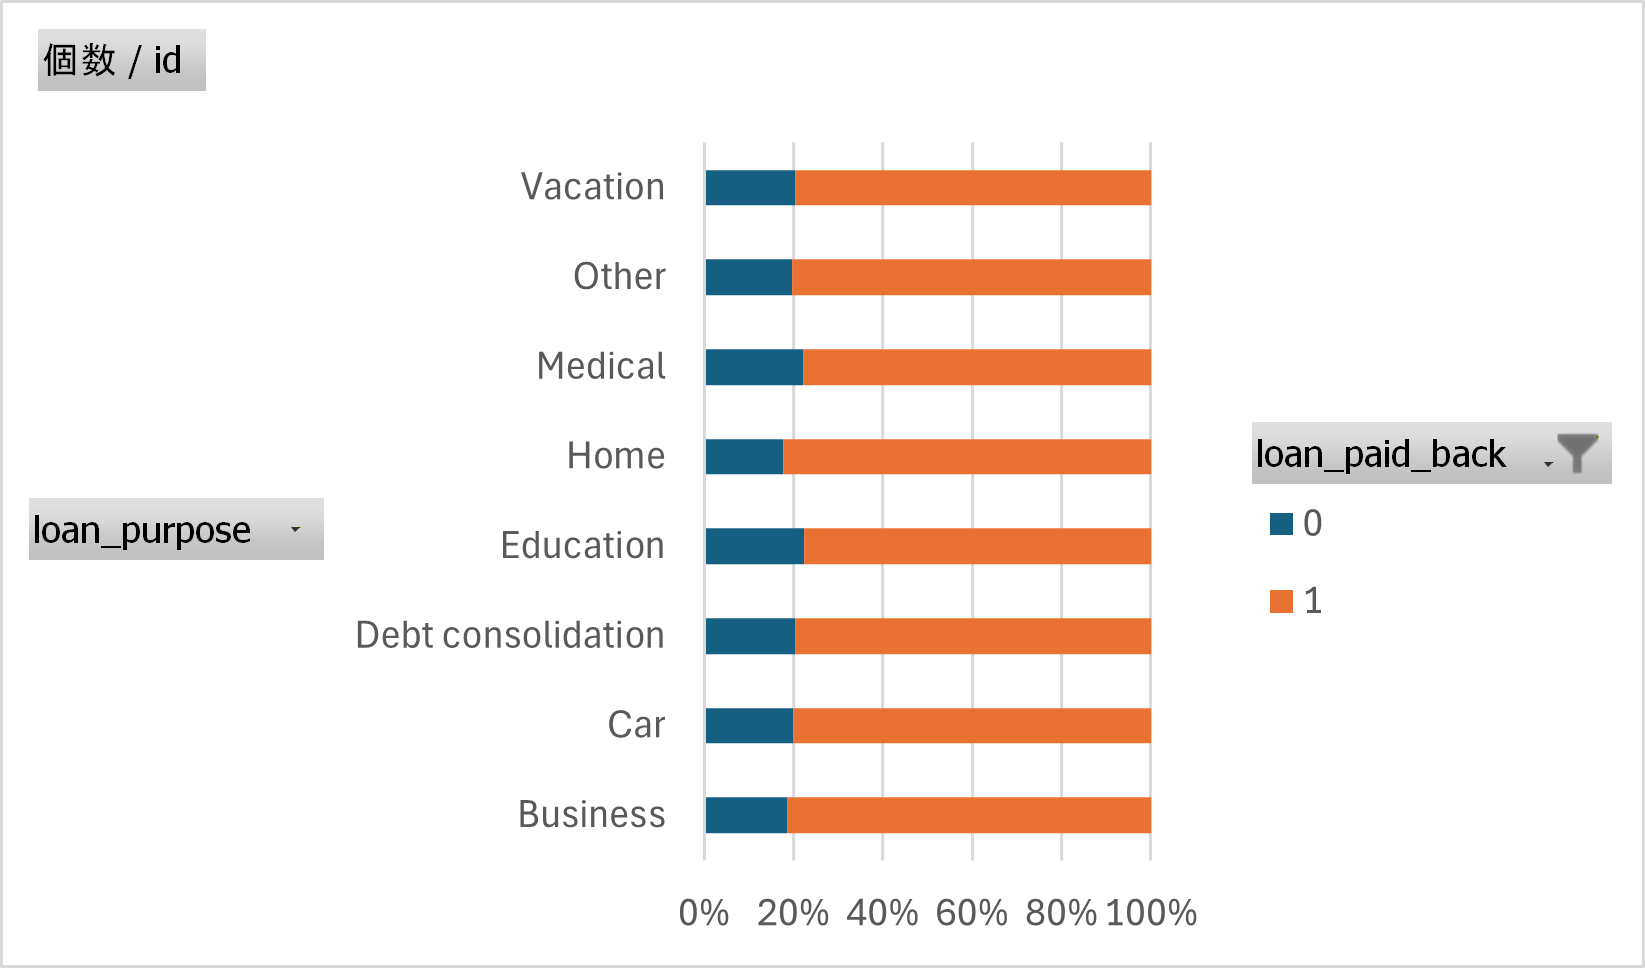

ローン返済している割合について

若干、差があった。

- **Home**の割合が高い 82%
- 続いて**Business** 81%
- 80%が**Other**,**Car**,**Debt consolidation**,**Vacation**
- 78%が**Medical**,**Education**

**gender**,**marital status**,**education level**は、項目によってローン返済有無の割合の大きな差は見られなかった。

## 特徴量エンジニアリング

### **annual income**

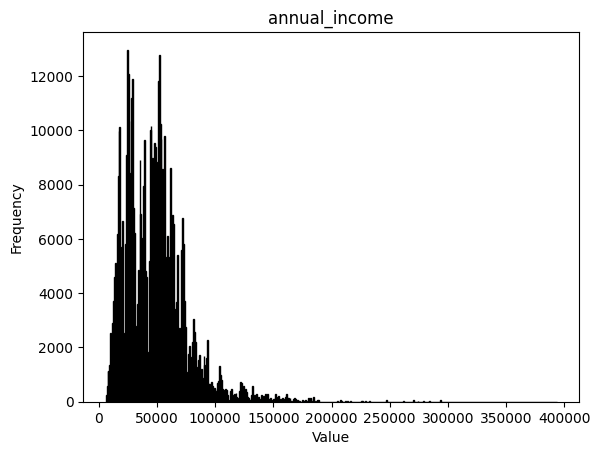

In [ ]:
# ヒストグラムを作成
plt.hist(train['annual_income'], bins='auto', color='skyblue', edgecolor='black')
plt.title('annual_income')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

分布補正

In [ ]:
train['log_income'] = np.log(train['annual_income'])
test['log_income'] = np.log(test['annual_income'])

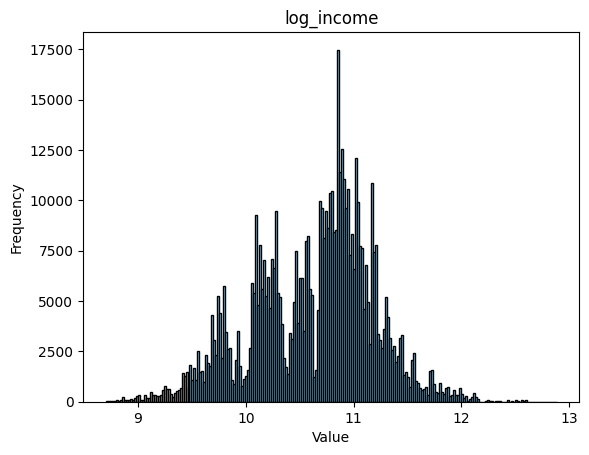

In [ ]:
# ヒストグラムを作成
plt.hist(train['log_income'], bins='auto', color='skyblue', edgecolor='black')
plt.title('log_income')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

### **debt to income ratio**

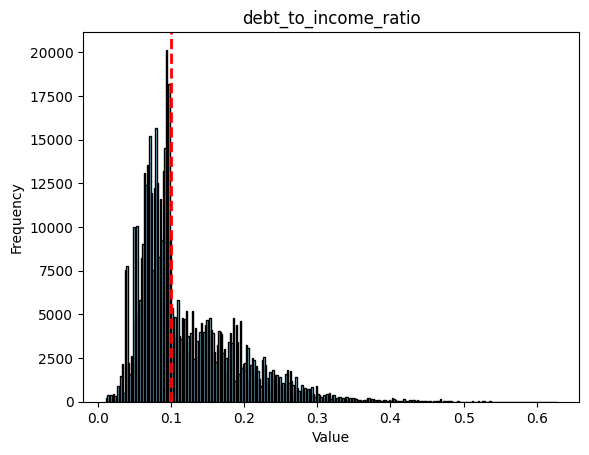

In [ ]:
# ヒストグラムを作成
plt.hist(train['debt_to_income_ratio'], bins='auto', color='skyblue', edgecolor='black')
# 閾値に縦線を引く
plt.axvline(0.1, color='red', linestyle='dashed', linewidth=2, label=0.1)
plt.title('debt_to_income_ratio')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

閾値0.1

二値化

In [ ]:
train["high_debt_flag"] = (train["debt_to_income_ratio"] > 0.1).astype(int)
test["high_debt_flag"] = (test["debt_to_income_ratio"] > 0.1).astype(int)

逆数変換：負担率が少ないほど返済能力が高い

In [ ]:
train["repayment_capacity"] = 1 / (train["debt_to_income_ratio"] + 1e-6)
test["repayment_capacity"] = 1 / (test["debt_to_income_ratio"] + 1e-6)

### **credit score**

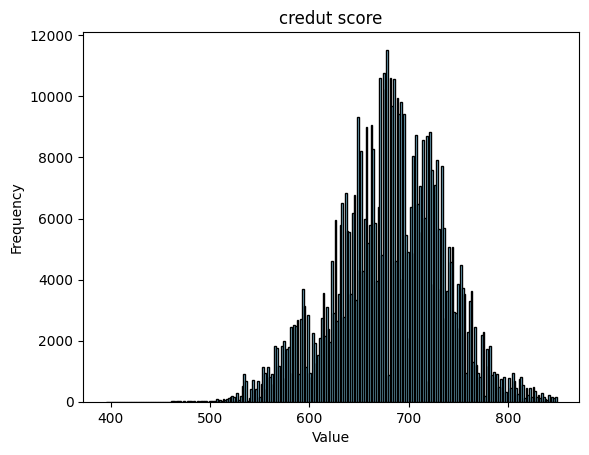

In [ ]:
# ヒストグラムを作成
plt.hist(train['credit_score'], bins='auto', color='skyblue', edgecolor='black')
plt.title('credut score')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

### **loan_amount**

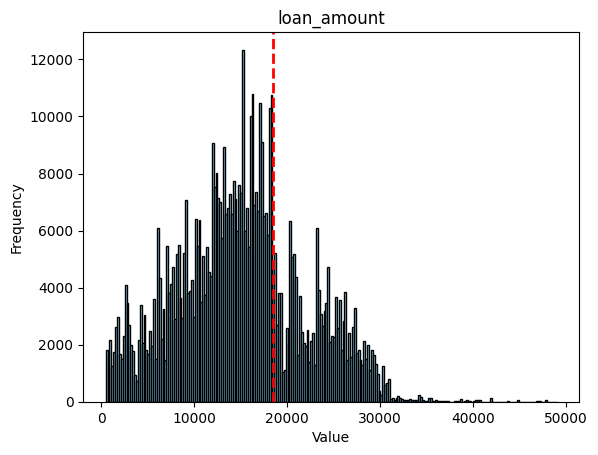

In [ ]:
# ヒストグラムを作成
plt.hist(train['loan_amount'], bins='auto', color='skyblue', edgecolor='black')
# 閾値に縦線を引く
plt.axvline(18500, color='red', linestyle='dashed', linewidth=2, label=0.1)
plt.title('loan_amount')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

### interest_rate

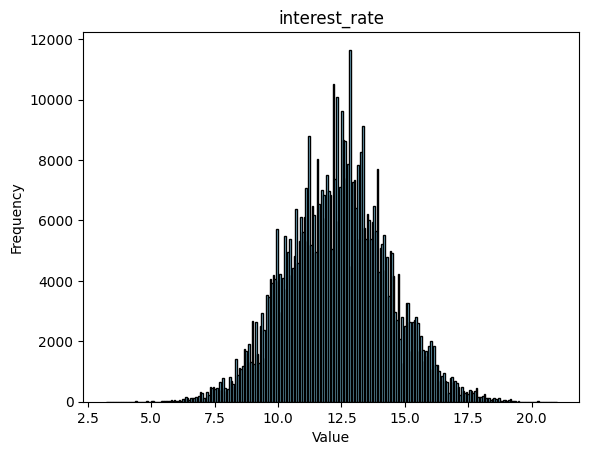

In [ ]:
# ヒストグラムを作成
plt.hist(train['interest_rate'], bins='auto', color='skyblue', edgecolor='black')
plt.title('interest_rate')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

### 交互作用

高負担×低所得

In [ ]:
train["high_debt_low_income"] = ((train["debt_to_income_ratio"] > 0.1) &
                              (train["annual_income"] < train["annual_income"].median())).astype(int)
test["high_debt_low_income"] = ((test["debt_to_income_ratio"] > 0.1) &
                              (test["annual_income"] < test["annual_income"].median())).astype(int)

同じ**credit_score**でも低金利のほうが優良

In [ ]:
train['credit_score_interest_log'] = np.log(train['credit_score'] / train['interest_rate'])
test['credit_score_interest_log'] = np.log(test['credit_score'] / test['interest_rate'])

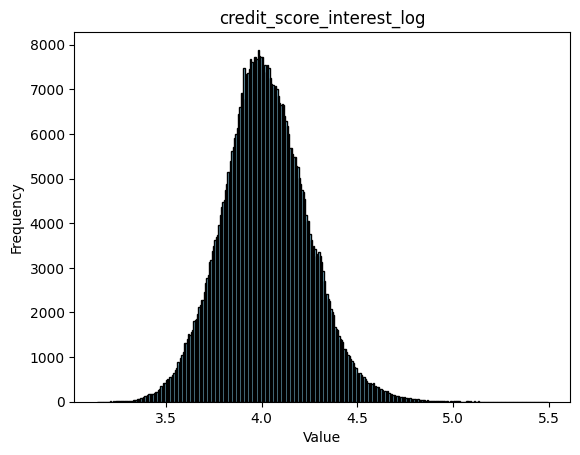

In [ ]:
# ヒストグラムを作成
plt.hist(train['credit_score_interest_log'], bins='auto', color='skyblue', edgecolor='black')
plt.title('credit_score_interest_log')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

返済能力：年収に対する融資額

In [ ]:
train['payback_ability'] = train['loan_amount'] / train['annual_income']
test['payback_ability'] = test['loan_amount'] / test['annual_income']

リスク：金利×融資額

In [ ]:
train['loan_burden'] = train['loan_amount']*train['interest_rate']
test['loan_burden'] = test['loan_amount']*test['interest_rate']

In [ ]:
print(train.columns.tolist())

['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_paid_back', 'log_income', 'high_debt_flag', 'repayment_capacity', 'high_debt_low_income', 'log_loan_amount']


カテゴリ変数

In [ ]:
# --- One-Hot Encoding ---
one_hot_cols = ['gender', 'marital_status','education_level']
train = pd.get_dummies(train, columns=one_hot_cols, drop_first=True)
test = pd.get_dummies(test, columns=one_hot_cols, drop_first=True)

# --- Ordinal Encoding ---
ordinal_cols = ['grade_subgrade']
# 等級など順序を定義する（データ内容に合わせて調整）
grade_order = ['F5','F4','F3','F2','F1','E5','E4','E3','E2','E1','D5','D4','D3','D2','D1','C5','C4','C3','C2','C1','B5','B4','B3','B2','B1','A5','A4','A3','A2','A1']
ordinal_mapping = [grade_order]
encoder = OrdinalEncoder(categories=ordinal_mapping)
train[ordinal_cols] = encoder.fit_transform(train[ordinal_cols])
test[ordinal_cols] = encoder.fit_transform(test[ordinal_cols])

# --- Frequency Encoding ---
freq_cols = ['loan_purpose']
for col in freq_cols:
    freq = train[col].value_counts(normalize=True)
    train[col + '_freq'] = train[col].map(freq)
train.drop(columns=freq_cols, inplace=True)
for col in freq_cols:
    freq = test[col].value_counts(normalize=True)
    test[col + '_freq'] = test[col].map(freq)
test.drop(columns=freq_cols, inplace=True)

# --- Target Encoding ---
target_col = 'loan_paid_back'
target_enc_cols = ['employment_status']
te = TargetEncoder(cols=target_enc_cols, smoothing=0.3)
train[target_enc_cols] = te.fit_transform(train[target_enc_cols], train[target_col])
test[target_enc_cols] = te.transform(test[target_enc_cols])

### モデル作成

In [ ]:
# --- 特徴量・目的変数 ---
target = 'loan_paid_back'
features = [
    'log_income',
    'debt_to_income_ratio',
    "high_debt_flag",
    "repayment_capacity",
    'credit_score',
    'loan_amount',
    'interest_rate',
    'high_debt_low_income',
    'credit_score_interest_log',
    'payback_ability',
    'loan_burden'
]+ [col for col in train.columns if '_freq' in col or '_status' in col or 'gender_' in col or 'marital_' in col or 'education_' in col]

X = train[features]
y = train[target]

In [ ]:
# --- train/test分割 ---
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# --- LGBMデータセット ---
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_valid, label=y_valid)

# --- モデル設定 ---
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42
}

# --- モデル学習 ---
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=100)]
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043984 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2311
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 22
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM] [Info] Start training from score 1.378932
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[579]	training's auc: 0.930476	valid_1's auc: 0.921368


In [ ]:
# --- 予測とAUC算出 ---
y_pred = model.predict(X_valid, num_iteration=model.best_iteration)
auc = roc_auc_score(y_valid, y_pred)
print(f"AUC: {auc:.4f}")

AUC: 0.9214


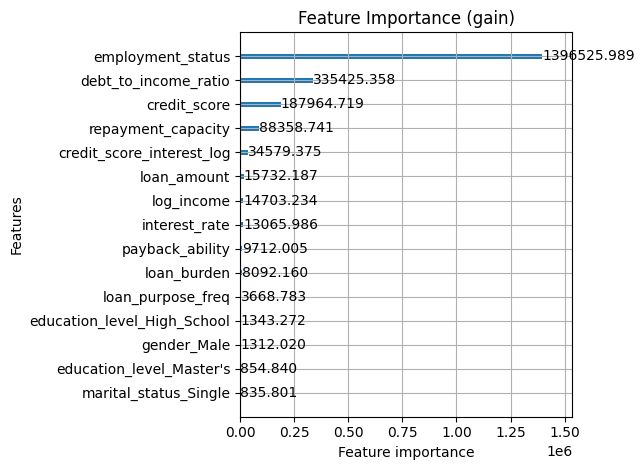

In [ ]:
# --- 特徴量重要度プロット ---
lgb.plot_importance(model, importance_type='gain', max_num_features=15)
plt.title("Feature Importance (gain)")
plt.tight_layout()
plt.show()

閾値を0.5に設定した場合

In [ ]:
test_features = test[features].reindex(columns=X.columns, fill_value=0)

# --- 予測 ---
y_pred_prob = model.predict(test_features)  # 確率出力（0〜1）

# --- 閾値を用いて0/1に変換 ---
threshold = 0.5
y_pred = (y_pred_prob >= threshold).astype(int)


# --- 提出用データフレーム作成 ---
submission = pd.DataFrame({
    'id': test['id'],
    'loan_paid_back': y_pred
})

# --- CSVとして保存 ---
submission.to_csv('submission2.csv', index=False)

print("✅ submission2.csv を出力しました。")


✅ submission2.csv を出力しました。


submission2.csvのスコアは、**0.79639**であった。

精度向上を図り、ROC曲線からYouden’s J統計量（= TPR - FPR）を最大化する点を探し、最適閾値を求めた。

In [ ]:
# --- 検証データで確率を予測 ---
y_valid_pred = model.predict(X_valid)

# --- ROC曲線を用いて最適閾値を算出 ---
fpr, tpr, thresholds = roc_curve(y_valid, y_valid_pred)
optimal_idx = np.argmax(tpr - fpr)  # Youden’s J = TPR - FPR を最大化
optimal_threshold = thresholds[optimal_idx]
print(f"🔹 最適閾値（Youden’s Jによる）: {optimal_threshold:.4f}")

🔹 最適閾値（Youden’s Jによる）: 0.7932


In [ ]:
test_features = test[features].reindex(columns=X.columns, fill_value=0)
# --- testデータで予測 ---
y_test_pred_prob = model.predict(test_features)

# --- 最適閾値で二値化 ---
y_test_pred = (y_test_pred_prob >= optimal_threshold).astype(int)

# --- 提出用データ作成 ---
submission = pd.DataFrame({
    'id': test['id'],
    'loan_paid_back': y_test_pred
})

# --- CSV出力 ---
submission.to_csv('submission.csv', index=False)

print("✅ submission.csv を出力しました。")


✅ submission.csv を出力しました。


最適閾値を0.7932とした結果、スコアは**0.83943**となり精度向上した。